# Stage 8 ABM — Calibration Progress & Calm vs Stressed Comparison

This notebook tells the calibration story end-to-end:

1. **Empirical reference**: WRDS daily SPY data — calm (2013-2014) vs stressed (Sept 2008 - Mar 2009).
2. **Direct calibration**: σ_v from data; one parameter per regime, scales 4.87× higher under stress.
3. **Behavioural calibration** (LHS over 5 free params + CIR vol-of-vol): how close sim moments come to empirical moments under each regime.
4. **Sim vs empirical side-by-side**: mid-vs-V tracking, return distribution, ACF(r), ACF(|r|) — Cont 2001 stylized facts.
5. **Agent-level diagnostics**: MM inventory + quote dynamics, BCM/NBCM cap_ratio trajectories, per-agent inventory and cash.

The goal is to see (a) whether V-relative scaling fixed the stress amplification we observed previously, and (b) how well the calibration matches the Cont 2001 stylized facts in both regimes.


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

from model.globals import ModelParams
from model.simulation import Simulation
from model.agents import (
    ZeroIntelligenceTrader, FundamentalTrader, MomentumTrader,
    BankingClearingMember, NonBankingClearingMember,
)
from run_simulation import build_traders
from calibrate import (
    extract_direct_params, empirical_moments_daily, make_params,
    _simulate_moments, compute_moments,
)

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})

# Calibrated parameter set — start from current best-known values
# (Stage 8 LHS top point); user should overwrite these after running
# `python calibrate.py lhs 200 90 3` on their machine.
FT_REL   = 0.005     # 50 bps (V-fraction) FT private valuation offset
MT_REL   = 0.005     # 50 bps MT placement spread
MT_LAM   = 0.95      # EWMA decay
KAPPA_V  = 0.10      # CIR mean-reversion speed (per 5-min step)
XI_V     = 1e-5      # CIR vol-of-vol

CALM_CSV   = 'data/thesis_data_calm.csv'
STRESS_CSV = 'data/thesis_data_stressed.csv'


## 1. Empirical reference data — calm vs stressed regimes

Load the WRDS daily SPY data and compute the Cont 2001 stylized fact targets for each regime.

In [15]:
def regime_summary(csv):
    df = pd.read_csv(csv).sort_values('date').reset_index(drop=True)
    log_oc = np.log(df['DPrice']/df['OPrice'])
    log_cc = np.log(df['DPrice']).diff().dropna()
    return df, log_oc, log_cc

calm_df, calm_log_oc, calm_log_cc = regime_summary(CALM_CSV)
stress_df, stress_log_oc, stress_log_cc = regime_summary(STRESS_CSV)

print(f'CALM    : {calm_df.date.min()} -> {calm_df.date.max()}  ({len(calm_df)} rows)')
print(f'  OPrice [{calm_df.OPrice.min():.2f}, {calm_df.OPrice.max():.2f}]')
print(f'  log_CC: std={calm_log_cc.std():.4f}  kurt={calm_log_cc.kurtosis():+.2f}  abs_max={calm_log_cc.abs().max():.4f}')
print()
print(f'STRESS  : {stress_df.date.min()} -> {stress_df.date.max()}  ({len(stress_df)} rows)')
print(f'  OPrice [{stress_df.OPrice.min():.2f}, {stress_df.OPrice.max():.2f}]')
print(f'  log_CC: std={stress_log_cc.std():.4f}  kurt={stress_log_cc.kurtosis():+.2f}  abs_max={stress_log_cc.abs().max():.4f}')

# Direct-calibrated parameters (regime-anchored)
calm_d   = extract_direct_params(CALM_CSV)
stress_d = extract_direct_params(STRESS_CSV)
print()
print(f'Direct sigma_v (5-min): calm={calm_d.sigma_v_per_5min:.3e}  stress={stress_d.sigma_v_per_5min:.3e}  '
      f'(stress/calm={stress_d.sigma_v_per_5min/calm_d.sigma_v_per_5min:.2f}x)')


CALM    : 2013-01-02 -> 2014-12-31  (503 rows)
  OPrice [145.11, 208.30]
  log_CC: std=0.0070  kurt=+1.34  abs_max=0.0253

STRESS  : 2008-09-02 -> 2009-03-31  (146 rows)
  OPrice [67.97, 130.06]
  log_CC: std=0.0341  kurt=+0.81  abs_max=0.1088

Direct sigma_v (5-min): calm=6.525e-04  stress=3.180e-03  (stress/calm=4.87x)


## 2. Empirical Cont 2001 moments — what we're trying to match

These are the targets the calibration objective tries to minimise distance to.

In [16]:
calm_t   = empirical_moments_daily(CALM_CSV)
stress_t = empirical_moments_daily(STRESS_CSV)

def fmt_moments(m, label):
    return (f'{label:>16}  std={m.ret_std:>7.4f}  kurt={m.ret_kurtosis_excess:>+6.2f}  '
            f'ACF(r,1)={m.acf_r_lag1:>+6.3f}  ACF(|r|,1)={m.acf_abs_r_lag1:>+6.3f}  '
            f'ACF(|r|,5)={m.acf_abs_r_lag5:>+6.3f}  ACF(|r|,20)={m.acf_abs_r_lag20:>+6.3f}')
print(fmt_moments(calm_t, 'calm target'))
print(fmt_moments(stress_t, 'stress target'))
print()
print('Cont 2001 stylized facts:')
print('  Fact #1: ACF(r, k>0) ~ 0       (returns near-uncorrelated)')
print('  Fact #2: kurt > 0              (heavy tails)')
print('  Fact #3: ACF(|r|, k) > 0       (vol clustering, slow decay)')


     calm target  std= 0.0070  kurt= +1.31  ACF(r,1)=-0.051  ACF(|r|,1)=+0.164  ACF(|r|,5)=+0.060  ACF(|r|,20)=-0.059
   stress target  std= 0.0340  kurt= +0.74  ACF(r,1)=-0.142  ACF(|r|,1)=-0.004  ACF(|r|,5)=+0.275  ACF(|r|,20)=+0.076

Cont 2001 stylized facts:
  Fact #1: ACF(r, k>0) ~ 0       (returns near-uncorrelated)
  Fact #2: kurt > 0              (heavy tails)
  Fact #3: ACF(|r|, k) > 0       (vol clustering, slow decay)


## 3. Run sims under both regimes (fix-agents-swap-environment)

Same calibrated behavioural params, only `v0`, `μ_v`, and CIR `θ_v` swap between regimes. Per-regime sim is a 60-day, 3-seed average so moments are well-estimated.

In [17]:
def run_regime(direct, n_steps=78*5, n_runs=3, seed=42):
    p = make_params(direct, FT_REL, MT_REL, MT_LAM, KAPPA_V,
                    direct.sigma_v_per_5min**2, XI_V)
    # We need both moments AND a single representative trace for plotting
    sim_m = _simulate_moments(p, seed=seed, n_steps=n_steps, n_runs=n_runs)
    # Single-trace simulation (one-day window) for visualization
    traders = build_traders(p, seed=seed)
    sim = Simulation(p, traders, seed=seed)
    inv_traj = defaultdict(list); cash_traj = defaultdict(list)
    quotes = []
    for _ in range(n_steps):
        sim.step()
        for t in sim.traders:
            inv_traj[t.agent_id].append(t.inventory)
            cash_traj[t.agent_id].append(t.cash)
    df = pd.DataFrame(sim.history)
    return p, sim, df, sim_m, inv_traj, cash_traj

import time; t0=time.perf_counter()
p_calm, sim_calm, df_calm, mom_calm, inv_calm, cash_calm = run_regime(calm_d, n_steps=78*60, n_runs=3)
p_stress, sim_stress, df_stress, mom_stress, inv_stress, cash_stress = run_regime(stress_d, n_steps=78*60, n_runs=3)
print(f'Both regimes ran in {time.perf_counter()-t0:.1f}s')
print()
print('SIMULATED moments (60 days, 3 seeds averaged):')
print(fmt_moments(mom_calm,   'calm sim'))
print(fmt_moments(mom_stress, 'stress sim'))


Both regimes ran in 9.8s

SIMULATED moments (60 days, 3 seeds averaged):
        calm sim  std= 0.0066  kurt= +0.06  ACF(r,1)=-0.136  ACF(|r|,1)=-0.060  ACF(|r|,5)=-0.100  ACF(|r|,20)=+0.013
      stress sim  std= 0.0279  kurt= -0.26  ACF(r,1)=-0.215  ACF(|r|,1)=+0.107  ACF(|r|,5)=-0.097  ACF(|r|,20)=-0.019


## 4. Sim vs empirical: side-by-side moment comparison

If the calibration is working, we expect the sim std to be within ±20% of empirical, ACF(r) close to 0, kurtosis positive, and ACF(|r|) at small lags positive.

In [18]:
def diff_pct(s, t): return (s/t - 1)*100 if t!=0 else float('nan')

def compare_table(target, sim, label):
    rows = [
        ('ret_std',           target.ret_std,           sim.ret_std),
        ('kurt_excess',       target.ret_kurtosis_excess, sim.ret_kurtosis_excess),
        ('ACF(r, 1)',         target.acf_r_lag1,        sim.acf_r_lag1),
        ('ACF(r, 5)',         target.acf_r_lag5,        sim.acf_r_lag5),
        ('ACF(|r|, 1)',       target.acf_abs_r_lag1,    sim.acf_abs_r_lag1),
        ('ACF(|r|, 5)',       target.acf_abs_r_lag5,    sim.acf_abs_r_lag5),
        ('ACF(|r|, 20)',      target.acf_abs_r_lag20,   sim.acf_abs_r_lag20),
    ]
    print(f'\n{label}:')
    print(f'  {"moment":<14} {"target":>10} {"sim":>10} {"sim/target":>12}')
    for name, t, s in rows:
        ratio = (s/t) if abs(t)>1e-3 else float('nan')
        print(f'  {name:<14} {t:>10.4f} {s:>10.4f} {ratio:>12.2f}')

compare_table(calm_t, mom_calm, 'CALM REGIME')
compare_table(stress_t, mom_stress, 'STRESS REGIME')

# Headline: did V-relative scales fix the amplification?
print()
print('=== AMPLIFICATION CHECK ===')
print(f'  STRESS sim_std / target_std: {mom_stress.ret_std/stress_t.ret_std:.3f}')
print(f'    (was 1.64 with absolute scales -> V-relative fix should bring near 1.0)')



CALM REGIME:
  moment             target        sim   sim/target
  ret_std            0.0070     0.0066         0.95
  kurt_excess        1.3117     0.0557         0.04
  ACF(r, 1)         -0.0507    -0.1363         2.69
  ACF(r, 5)         -0.0618     0.0430        -0.70
  ACF(|r|, 1)        0.1639    -0.0598        -0.36
  ACF(|r|, 5)        0.0604    -0.1001        -1.66
  ACF(|r|, 20)      -0.0590     0.0131        -0.22

STRESS REGIME:
  moment             target        sim   sim/target
  ret_std            0.0340     0.0279         0.82
  kurt_excess        0.7370    -0.2645        -0.36
  ACF(r, 1)         -0.1419    -0.2151         1.52
  ACF(r, 5)         -0.0582    -0.1307         2.25
  ACF(|r|, 1)       -0.0045     0.1074       -23.91
  ACF(|r|, 5)        0.2747    -0.0965        -0.35
  ACF(|r|, 20)       0.0758    -0.0191        -0.25

=== AMPLIFICATION CHECK ===
  STRESS sim_std / target_std: 0.823
    (was 1.64 with absolute scales -> V-relative fix should bring near 1

## 5. Mid-price vs fundamental V — both regimes

How well does the simulated mid track the (now CIR-stochastic) fundamental in each regime?

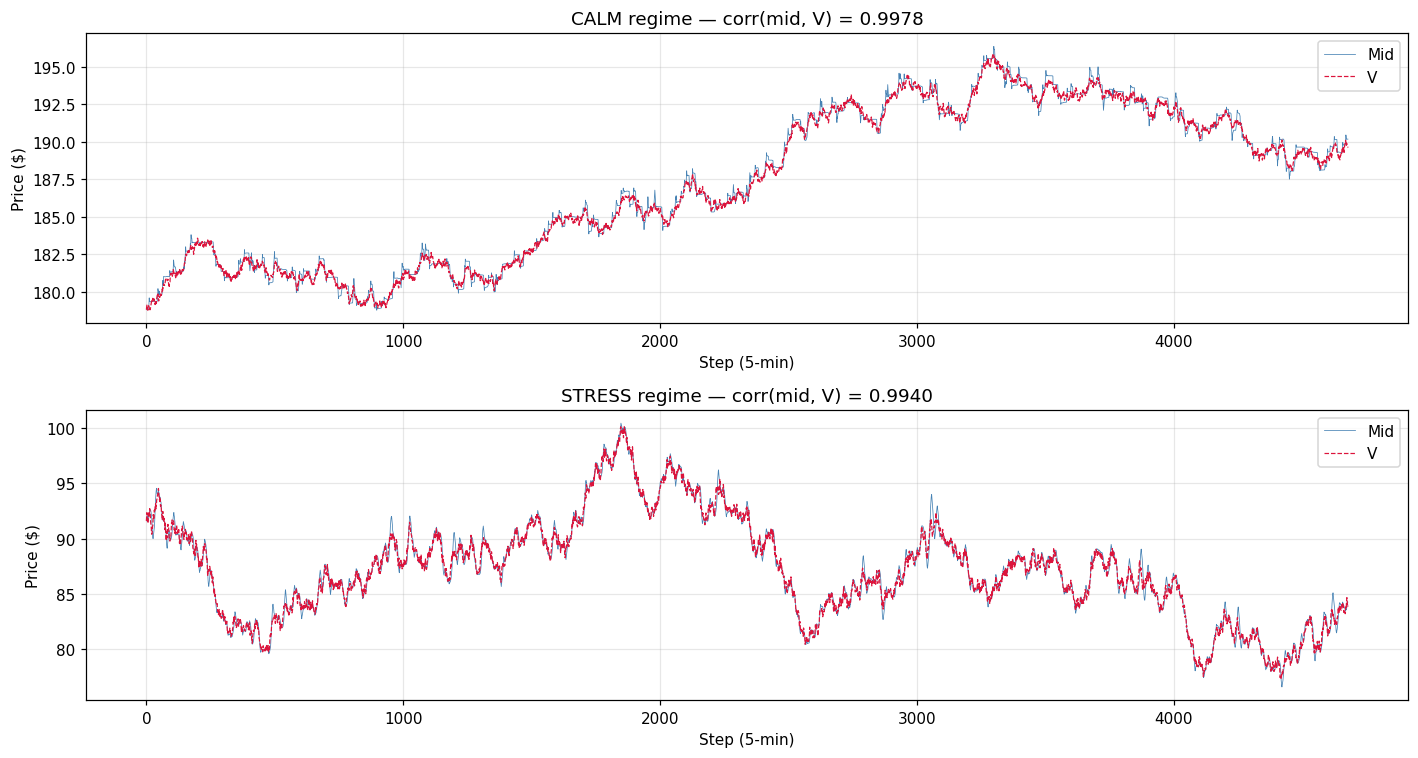

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7))
for ax, df, label in [(axes[0], df_calm, 'CALM'), (axes[1], df_stress, 'STRESS')]:
    ax.plot(df['t'], df['mid_price'], lw=0.5, label='Mid', color='steelblue')
    ax.plot(df['t'], df['fundamental'], lw=0.8, ls='--', color='crimson', label='V')
    ax.set_xlabel('Step (5-min)')
    ax.set_ylabel('Price ($)')
    corr = df[['mid_price','fundamental']].corr().iloc[0,1]
    ax.set_title(f'{label} regime — corr(mid, V) = {corr:.4f}')
    ax.legend()
plt.tight_layout(); plt.show()


## 6. Return distribution — sim vs empirical

Histograms of daily log-returns: simulated overlaid on empirical. Look for shape match (kurtosis, tails) and scale match (std).

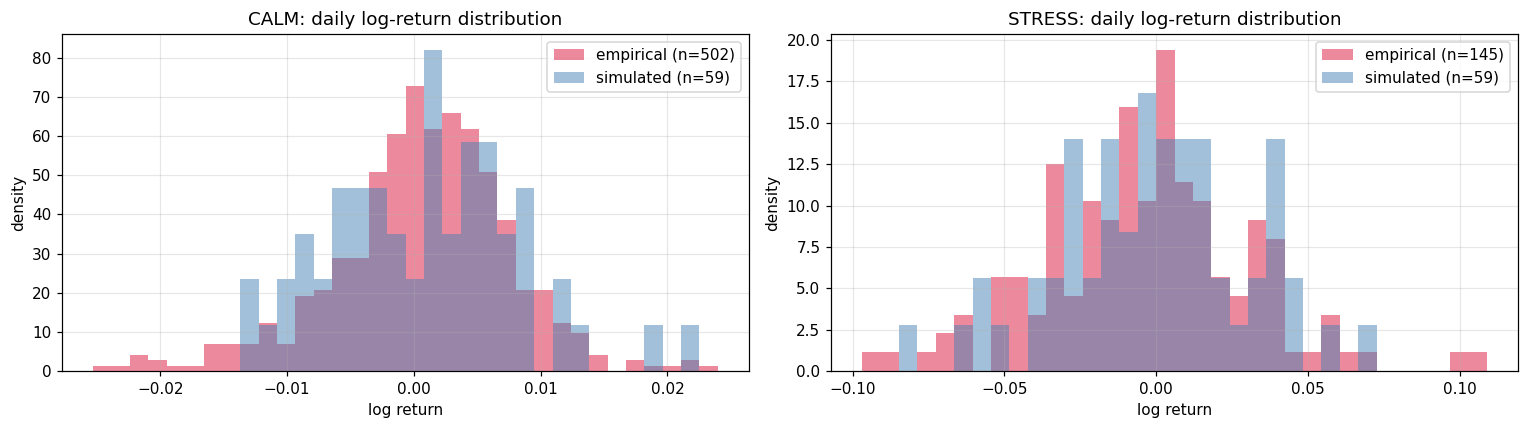

In [20]:
def daily_returns(df, bars_per_day=78):
    mid = df['mid_price'].ffill().bfill().values
    n_days = len(mid)//bars_per_day
    eod = mid[bars_per_day-1::bars_per_day][:n_days]
    return np.diff(np.log(eod))

sim_calm_r   = daily_returns(df_calm)
sim_stress_r = daily_returns(df_stress)
emp_calm_r   = calm_log_cc.values
emp_stress_r = stress_log_cc.values

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, label, sim_r, emp_r in [
    (axes[0], 'CALM', sim_calm_r, emp_calm_r),
    (axes[1], 'STRESS', sim_stress_r, emp_stress_r),
]:
    bins = np.linspace(min(emp_r.min(), sim_r.min()),
                       max(emp_r.max(), sim_r.max()), 35)
    ax.hist(emp_r, bins=bins, alpha=0.5, color='crimson', label=f'empirical (n={len(emp_r)})', density=True)
    ax.hist(sim_r, bins=bins, alpha=0.5, color='steelblue', label=f'simulated (n={len(sim_r)})', density=True)
    ax.set_title(f'{label}: daily log-return distribution')
    ax.set_xlabel('log return'); ax.set_ylabel('density'); ax.legend()
plt.tight_layout(); plt.show()


## 7. Autocorrelation structure — Cont 2001 facts overlaid

Sim and empirical ACFs of returns and |returns| on the same axes. Visual check on whether the sim is reproducing the persistence structure.

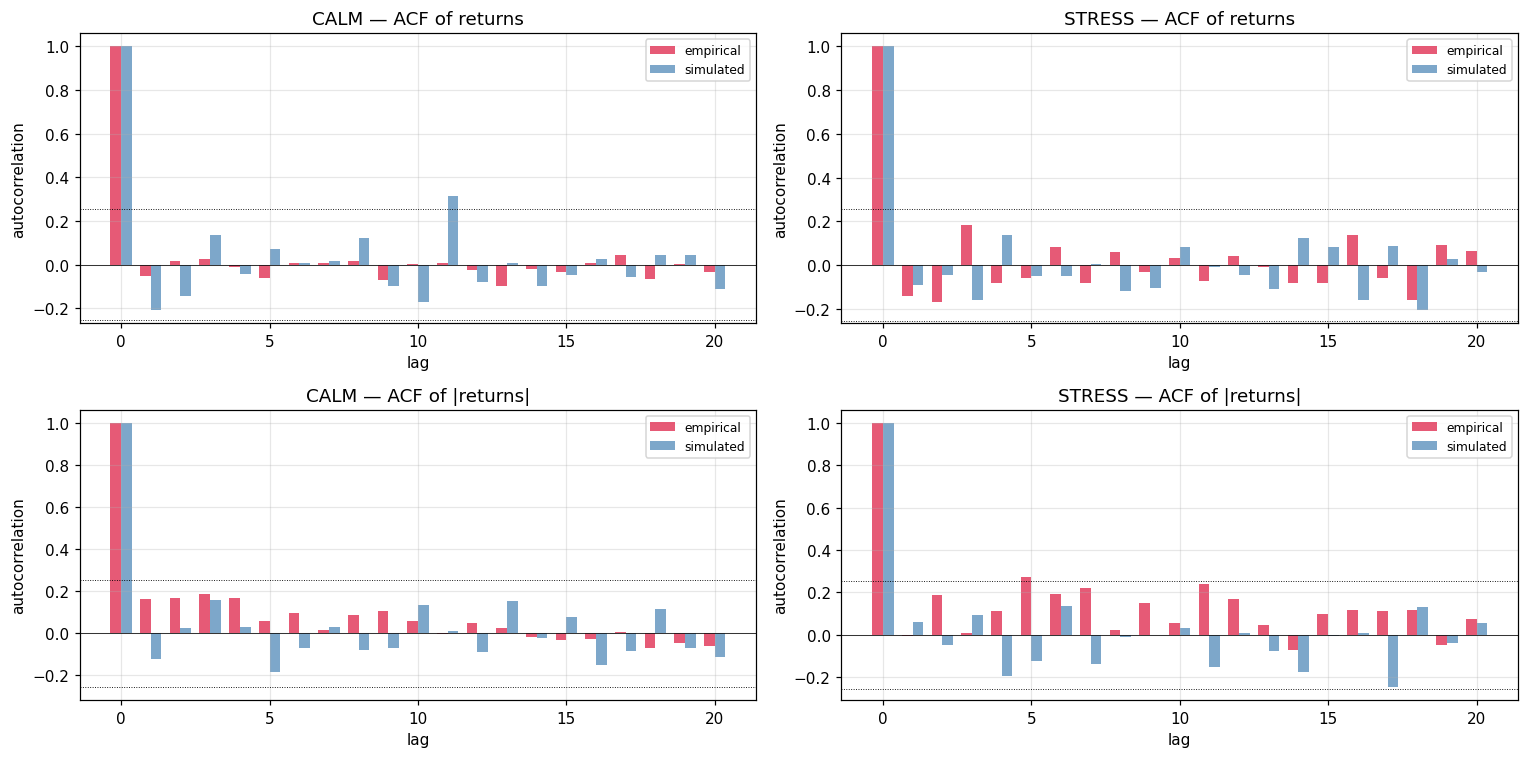

In [21]:
def acf_seq(x, max_lag=20):
    x = np.asarray(x, dtype=float); x = x - x.mean(); var = (x*x).sum()
    return [1.0] + [(x[:-k]*x[k:]).sum()/var for k in range(1, max_lag+1)]

ks = np.arange(0, 21)
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
for col, (label, emp_r, sim_r) in enumerate([
    ('CALM', emp_calm_r, sim_calm_r),
    ('STRESS', emp_stress_r, sim_stress_r),
]):
    for row, (which, transform) in enumerate([('returns', lambda x: x), ('|returns|', np.abs)]):
        ax = axes[row, col]
        emp_acf = acf_seq(transform(emp_r))
        sim_acf = acf_seq(transform(sim_r))
        ax.bar(ks-0.18, emp_acf, width=0.36, color='crimson', label='empirical', alpha=0.7)
        ax.bar(ks+0.18, sim_acf, width=0.36, color='steelblue', label='simulated', alpha=0.7)
        ci = 1.96/np.sqrt(min(len(emp_r), len(sim_r)))
        ax.axhline(ci, color='k', ls=':', lw=0.6); ax.axhline(-ci, color='k', ls=':', lw=0.6)
        ax.axhline(0, color='k', lw=0.5)
        ax.set_title(f'{label} — ACF of {which}')
        ax.set_xlabel('lag'); ax.set_ylabel('autocorrelation'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


## 8. CIR variance trajectory — vol-regime dynamics

The fundamental's instantaneous variance follows a CIR (Heston) process. Plot v_var over time and verify it stays positive and reverts to θ_v.

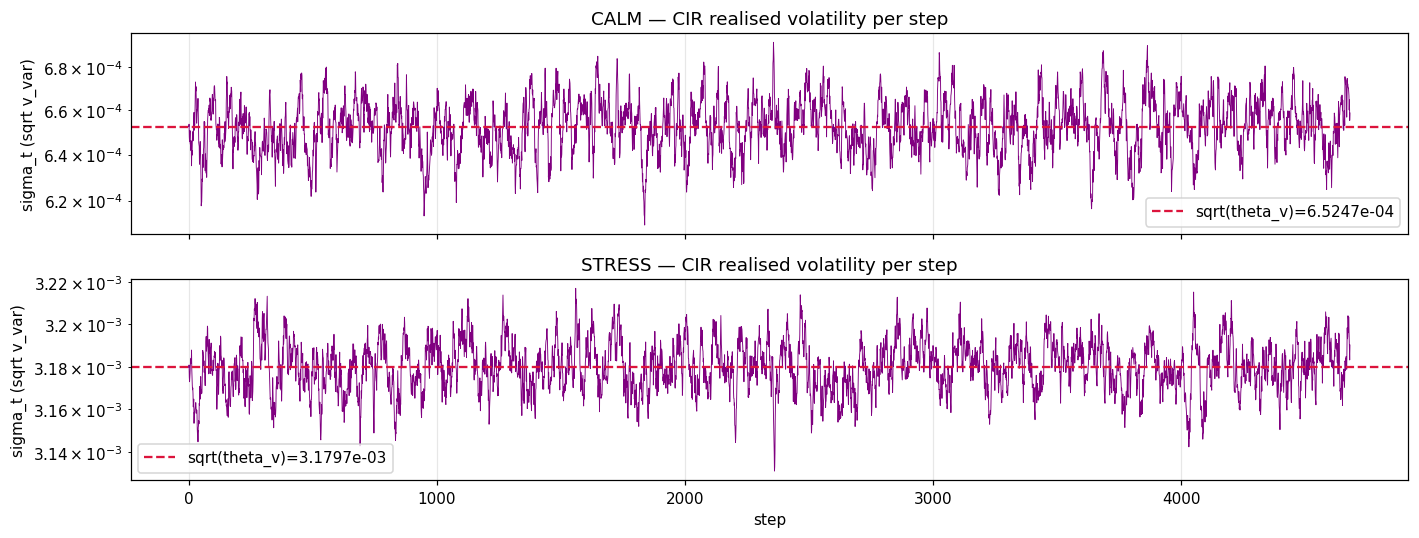

In [22]:
# Re-run a single-seed sim to capture v_var trajectory
def run_with_var(direct, n_steps, seed=42):
    p = make_params(direct, FT_REL, MT_REL, MT_LAM, KAPPA_V,
                    direct.sigma_v_per_5min**2, XI_V)
    traders = build_traders(p, seed=seed)
    sim = Simulation(p, traders, seed=seed)
    v_var_traj = []
    for _ in range(n_steps):
        v_var_traj.append(sim.gs.v_var)
        sim.step()
    return p, np.array(v_var_traj)

p_c2, v_calm = run_with_var(calm_d, 78*60)
p_s2, v_stress = run_with_var(stress_d, 78*60)

fig, axes = plt.subplots(2, 1, figsize=(13, 5), sharex=True)
for ax, vv, label, theta in [
    (axes[0], v_calm,   'CALM',   p_c2.theta_v),
    (axes[1], v_stress, 'STRESS', p_s2.theta_v),
]:
    ax.plot(np.sqrt(vv), lw=0.6, color='purple')
    ax.axhline(np.sqrt(theta), ls='--', color='crimson', label=f'sqrt(theta_v)={np.sqrt(theta):.4e}')
    ax.set_yscale('log')
    ax.set_ylabel('sigma_t (sqrt v_var)')
    ax.set_title(f'{label} — CIR realised volatility per step')
    ax.legend()
axes[1].set_xlabel('step')
plt.tight_layout(); plt.show()


## 9. MM inventory + quote dynamics

Per HFABM (Cao 2024), MM inventory tells the story of liquidity provision: under shocks, inventory builds up; quotes get skewed; if the inventory limit is hit, MM has to liquidate. We don't have a hard inventory limit yet (planned extension), but we can see the natural inventory accumulation.

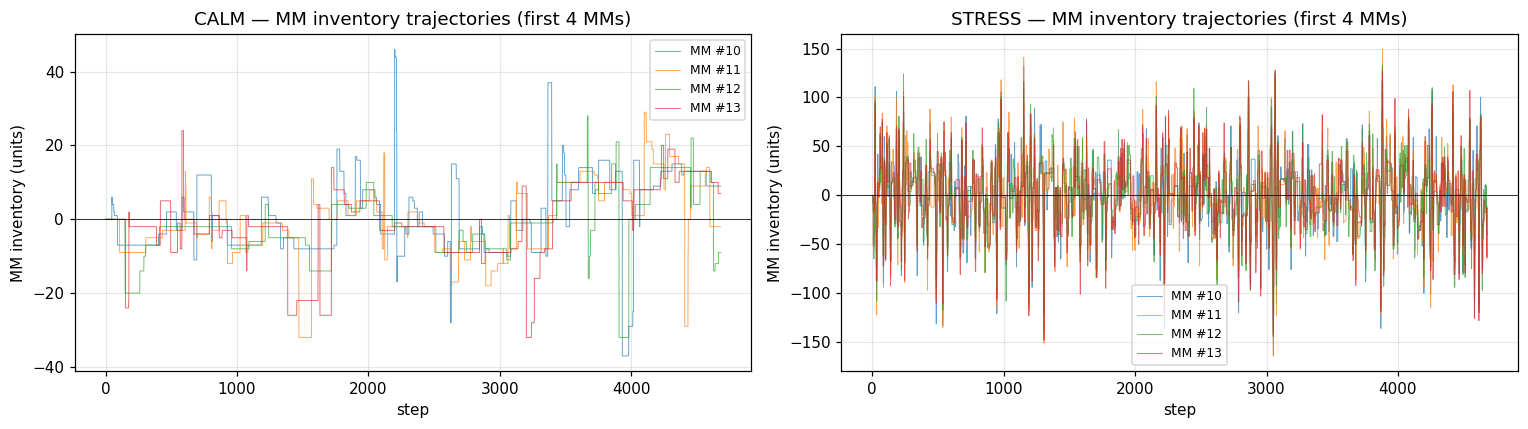

In [23]:
def mm_diagnostics(sim, inv_traj):
    mms = [t for t in sim.traders if isinstance(t, BankingClearingMember) and t.mode=='market_maker']
    return mms[:4], inv_traj  # first 4 MMs

mms_c, _ = mm_diagnostics(sim_calm, inv_calm)
mms_s, _ = mm_diagnostics(sim_stress, inv_stress)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, mms, inv_traj, label in [
    (axes[0], mms_c, inv_calm,   'CALM'),
    (axes[1], mms_s, inv_stress, 'STRESS'),
]:
    for mm in mms:
        ax.plot(inv_traj[mm.agent_id], lw=0.6, alpha=0.7, label=f'MM #{mm.agent_id}')
    ax.set_xlabel('step'); ax.set_ylabel('MM inventory (units)')
    ax.set_title(f'{label} — MM inventory trajectories (first 4 MMs)')
    ax.axhline(0, color='k', lw=0.5)
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


## 10. CM capital ratios — both regimes

Aggregate cap_ratio per CM type. Under stress (4.87× vol), cap_ratios should compress somewhat as inventory swings grow. The 8% Basel floor is unlikely to be breached at calm-period agent cash levels but tracking is important for Stage 4 margin layer.

/var/folders/n1/hz9fp9dj5wd300076k89wf200000gp/T/ipykernel_64248/1483740048.py:16: RuntimeWarning: divide by zero encountered in divide
  cap = np.where(notional > 0, cm_cash / notional, np.inf)


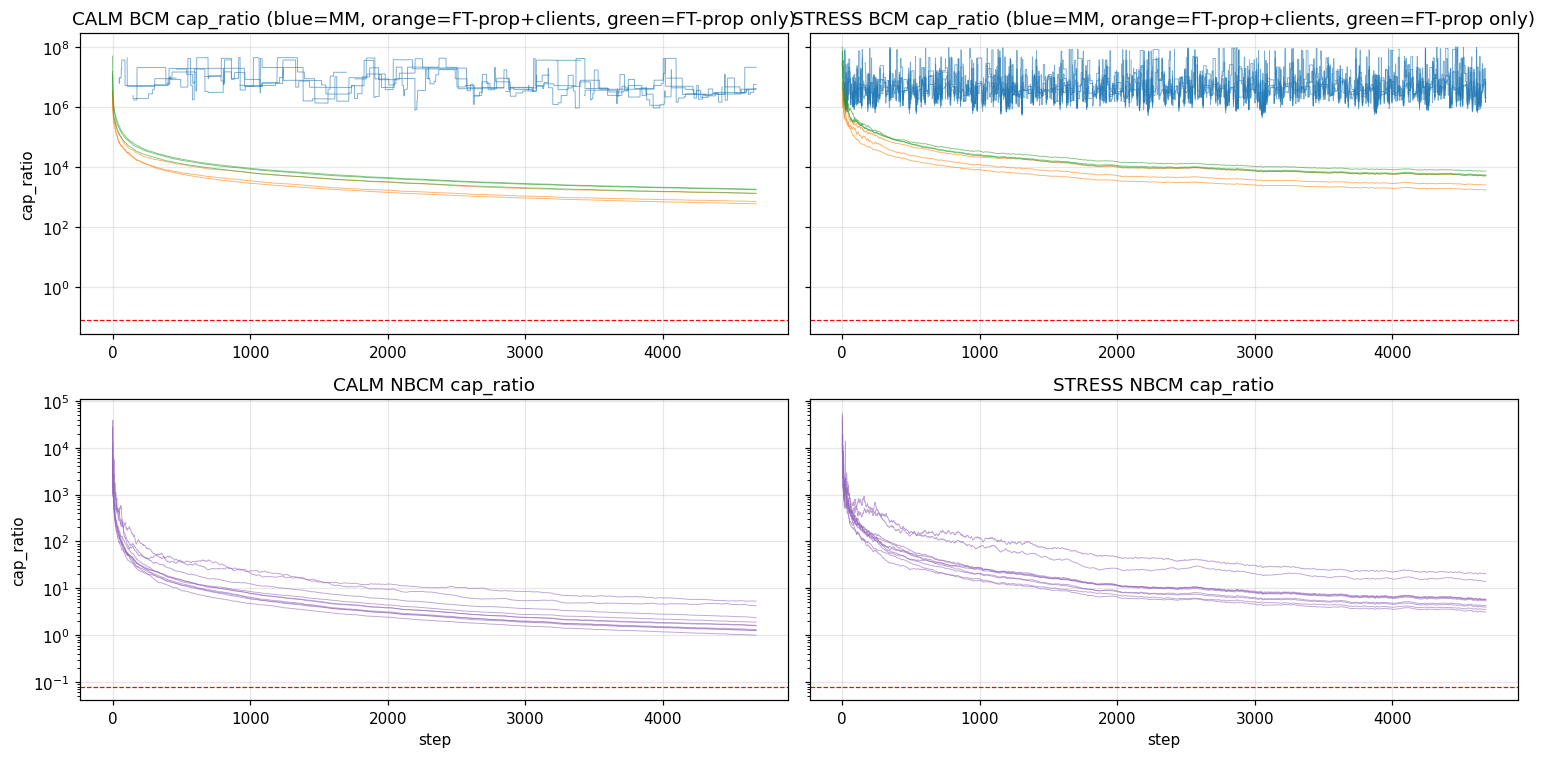

CALM min cap_ratio by CM:
  BankingClearing mode=market_maker   min=8.04e+05
  BankingClearing mode=market_maker   min=1.39e+06
  BankingClearing mode=market_maker   min=1.17e+06
  BankingClearing mode=market_maker   min=1.25e+06
  BankingClearing mode=fundamental    min=1.34e+03
  BankingClearing mode=fundamental    min=7.31e+02
  BankingClearing mode=fundamental    min=6.12e+02
  BankingClearing mode=fundamental    min=1.80e+03
  BankingClearing mode=fundamental    min=1.88e+03
  BankingClearing mode=fundamental    min=1.37e+03

STRESS min cap_ratio by CM:
  BankingClearing mode=market_maker   min=4.53e+05
  BankingClearing mode=market_maker   min=5.47e+05
  BankingClearing mode=market_maker   min=5.51e+05
  BankingClearing mode=market_maker   min=5.85e+05
  BankingClearing mode=fundamental    min=5.18e+03
  BankingClearing mode=fundamental    min=2.59e+03
  BankingClearing mode=fundamental    min=1.77e+03
  BankingClearing mode=fundamental    min=7.44e+03
  BankingClearing mode=fund

In [24]:
def reconstruct_cap_ratios(sim, df, inv_traj, cash_traj):
    mid = df['mid_price'].ffill().fillna(sim.gs.params.v0).values
    cm_data = []
    for cm in sim.traders:
        if not isinstance(cm, (BankingClearingMember, NonBankingClearingMember)):
            continue
        own_inv = np.array(inv_traj[cm.agent_id], dtype=float)
        client_inv = np.zeros_like(own_inv)
        for cid in cm.client_ids:
            client_inv += np.abs(np.array(inv_traj[cid], dtype=float))
        cm_cash = np.array(cash_traj[cm.agent_id], dtype=float)
        if isinstance(cm, BankingClearingMember):
            notional = (np.abs(own_inv) + client_inv) * mid
        else:
            notional = client_inv * mid
        cap = np.where(notional > 0, cm_cash / notional, np.inf)
        cm_data.append((cm, cap))
    return cm_data

cap_calm   = reconstruct_cap_ratios(sim_calm,   df_calm,   inv_calm,   cash_calm)
cap_stress = reconstruct_cap_ratios(sim_stress, df_stress, inv_stress, cash_stress)

fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharey='row')
for col, (cm_data, df_x, label) in enumerate([
    (cap_calm,   df_calm,   'CALM'),
    (cap_stress, df_stress, 'STRESS'),
]):
    for cm, cap in cm_data:
        cap_clip = np.where(np.isinf(cap), np.nan, cap)
        if isinstance(cm, BankingClearingMember):
            color = 'tab:blue' if cm.mode=='market_maker' else ('tab:orange' if cm.client_ids else 'tab:green')
            axes[0, col].plot(df_x['t'], cap_clip, lw=0.6, alpha=0.6, color=color)
        else:
            axes[1, col].plot(df_x['t'], cap_clip, lw=0.6, alpha=0.6, color='tab:purple')
    axes[0, col].axhline(0.08, color='red', ls='--', lw=0.8)
    axes[1, col].axhline(0.08, color='red', ls='--', lw=0.8)
    axes[0, col].set_yscale('log'); axes[1, col].set_yscale('log')
    axes[0, col].set_title(f'{label} BCM cap_ratio (blue=MM, orange=FT-prop+clients, green=FT-prop only)')
    axes[1, col].set_title(f'{label} NBCM cap_ratio')
    axes[1, col].set_xlabel('step')
axes[0, 0].set_ylabel('cap_ratio'); axes[1, 0].set_ylabel('cap_ratio')
plt.tight_layout(); plt.show()

# Min cap ratio per CM
def min_cap_summary(cm_data, label):
    mins = [(type(cm).__name__, cm.mode if isinstance(cm, BankingClearingMember) else '-',
             float(np.nanmin(np.where(np.isinf(c), np.nan, c)))) for cm, c in cm_data]
    print(f'{label} min cap_ratio by CM:')
    for tname, mode, mc in mins[:10]:
        print(f'  {tname[:15]:15} mode={mode:14} min={mc:.2e}')
min_cap_summary(cap_calm,   'CALM')
print()
min_cap_summary(cap_stress, 'STRESS')


## 11. Per-agent state by type — end of run

Inventory + cash distribution by agent type. Total inventory must be 0 (conservation); cash is conserved up to floating-point error.

In [25]:
def end_state(sim, label):
    rows = []
    for t in sim.traders:
        rows.append({'agent_id': t.agent_id, 'type': type(t).__name__,
                     'mode': getattr(t, 'mode', '-'),
                     'inventory': t.inventory, 'cash': t.cash})
    df = pd.DataFrame(rows)
    print(f'\n=== {label} end-of-run state ===')
    print(f'  total inventory: {df.inventory.sum()}  (should be 0)')
    print(df.groupby('type').agg(count=('agent_id','count'),
                                  inv_mean=('inventory','mean'),
                                  inv_std=('inventory','std'),
                                  inv_max_abs=('inventory', lambda x: x.abs().max())).round(2))

end_state(sim_calm, 'CALM')
end_state(sim_stress, 'STRESS')



=== CALM end-of-run state ===
  total inventory: 0  (should be 0)
                          count  inv_mean   inv_std  inv_max_abs
type                                                            
BankingClearingMember        10  -4022.90  17823.09        25790
FundamentalTrader            13   2987.00  21019.61        25696
MomentumTrader               13    729.62   5098.13         6861
NonBankingClearingMember     10      0.00      0.00            0
ZeroIntelligenceTrader       23   -351.61    275.82          909

=== STRESS end-of-run state ===
  total inventory: 0  (should be 0)
                          count  inv_mean   inv_std  inv_max_abs
type                                                            
BankingClearingMember        10  -3068.90  10725.68        19433
FundamentalTrader            13   2138.31  12649.74        20994
MomentumTrader               13    -92.85   7849.63        10625
NonBankingClearingMember     10      0.00      0.00            0
ZeroIntelligenceTra

## 12. Calibration progress — load LHS results if present

If you've run `python calibrate.py lhs 200 90 3` (recommended overnight on your laptop), this loads the result and shows the loss landscape across the search.

In [26]:
import os
csv_path = 'output/calibration_lhs.csv'
if os.path.exists(csv_path):
    cal = pd.read_csv(csv_path).sort_values('loss').reset_index(drop=True)
    print(f'LHS results loaded: {len(cal)} samples')
    print('\nTOP 10:')
    print(cal.head(10).to_string(index=False))
    print('\nBest parameters:')
    best = cal.iloc[0].to_dict()
    for k, v in best.items():
        print(f'  {k:14} {v}')

    fig, axes = plt.subplots(2, 3, figsize=(14, 7))
    for ax, col in zip(axes.ravel(), ['ft_sigma', 'mt_sigma', 'mt_lambda', 'kappa_v', 'log10_xi', 'loss']):
        if col == 'loss':
            ax.hist(cal['loss'], bins=30, color='steelblue', alpha=0.7)
            ax.set_xlabel('loss'); ax.set_title('Loss distribution')
        else:
            ax.scatter(cal[col], cal['loss'], s=10, alpha=0.5)
            ax.set_xlabel(col); ax.set_ylabel('loss'); ax.set_title(f'loss vs {col}')
    plt.tight_layout(); plt.show()
else:
    print('No LHS results yet — run:  python calibrate.py lhs 200 90 3')
    print('to generate output/calibration_lhs.csv (~10 minutes wall time).')


No LHS results yet — run:  python calibrate.py lhs 200 90 3
to generate output/calibration_lhs.csv (~10 minutes wall time).
